# US Airline Sentiment Classification using Word2Vec and ANN

This notebook presents a complete pipeline for sentiment classification using:
- Text preprocessing
- Word2Vec embeddings
- Artificial Neural Network (ANN)

In this notebook, we build a sentiment classification model for airline tweets.

We start by exploring the dataset and applying basic text preprocessing, including cleaning, tokenization, and stopword removal.

Then, we use Word2Vec to transform words into vector representations and represent each tweet as the average of its word embeddings.

These vectors are used as input to a feed-forward neural network (ANN) for classification into three sentiment classes: negative, neutral, and positive.

To improve performance, we apply early stopping and handle class imbalance using weighted loss.

Finally, we evaluate the model using accuracy, precision, recall, F1-score, and a confusion matrix.

In [56]:
import pandas as pd
import numpy as np
import re
import string
# import nltk
# import spacy
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
import os
from sklearn.model_selection import train_test_split
from collections import Counter
from nltk.corpus import stopwords
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import copy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim

In [57]:
# Load Dataset
def load_dataset(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    return df

In [58]:
#  Feed-forward neural network for 3-class sentiment classification
#     using Word2Vec input vectors.
class ANNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim,
                 dropout_p1=0.3, dropout_p2=0.2):
        super(ANNClassifier, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)

        self.dropout1 = nn.Dropout(p=dropout_p1)
        self.dropout2 = nn.Dropout(p=dropout_p2)

    def forward(self, x):
        # First layer
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)

        # Second layer
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)

        # Output
        x = self.fc3(x)

        return x


In [59]:
# inspect_dataset
def inspect_dataset(df: pd.DataFrame, target_column: str) -> None:

    print("Shape of dataset:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    print(df.head())

    print("\nDataset info:")
    df.info()

    print("\nMissing values per column:")
    print(df.isnull().sum())

    print(f"\nUnique values in '{target_column}':")
    print(df[target_column].unique())

    print(f"\nClass distribution for '{target_column}':")
    print(df[target_column].value_counts())

In [60]:
# selected columns
def select_columns(df: pd.DataFrame) -> pd.DataFrame:
    selected_df = df[['text', 'airline_sentiment']].copy()
    return selected_df

In [61]:
# Cleaning method
def clean_and_tokenize_text(text: str, stop_words: set) -> list:

    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    # Remove mentions
    text = re.sub(r"@\w+", "", text)
    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)
    # Replace HTML artifact
    text = re.sub(r"&amp;", "and", text)
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Remove digits
    text = re.sub(r"\d+", "", text)
    # Regex tokenization
    tokens = re.findall(r"[a-zA-Z]+", text)
    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]


    return tokens

In [62]:
# data preprocessipreprocessing 
def preprocess_dataset(df: pd.DataFrame, text_column: str) -> pd.DataFrame:

    stop_words = set(stopwords.words("english"))
    custom_stopwords = {"flight", "flights", "plane", "airline", "get"}  # If irrelevant
    final_stopwords = stop_words.union(custom_stopwords)

    df = df.copy()
    df["cleaned_tokens"] = df[text_column].apply(lambda x: clean_and_tokenize_text(x, final_stopwords))

    return df

In [63]:
def inspect_preprocessed_data(df: pd.DataFrame, text_column: str, top_n: int = 30) -> None:

    print("\nSample original and cleaned tweets:")
    print(df[[text_column, "cleaned_tokens"]].head())

    empty_tweets = (df["cleaned_tokens"].apply(len) == 0).sum()
    print(f"\nNumber of empty tweets after preprocessing: {empty_tweets}")

    all_tokens = [token for tokens in df["cleaned_tokens"] for token in tokens]
    most_common_words = Counter(all_tokens).most_common(top_n)

    print(f"\nTop {top_n} most frequent words:")
    for word, count in most_common_words:
        print(f"{word}: {count}")

In [64]:
# Trains a Word2Vec model on tokenized sentences.
def train_word2vec(tokenized_sentences: list,
                   vector_size: int = 100,
                   window: int = 5,
                   min_count: int = 2,
                   workers: int = 4) -> Word2Vec:

    model = Word2Vec(
        sentences=tokenized_sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers
    )
    return model

In [65]:
# Prints the most similar words for a list of test words.
def inspect_similar_words(model: Word2Vec, test_words: list, top_n: int = 5) -> None:

    print("\nMost similar words:")

    for word in test_words:
        print(f"\nWord: '{word}'")

        if word in model.wv:
            similar_words = model.wv.most_similar(word, topn=top_n)
            for similar_word, score in similar_words:
                print(f"{similar_word}: {score:.4f}")
        else:
            print("Word not in vocabulary.")

In [66]:
# Converts a tokenized tweet into a fixed-size vector by averaging the embeddings of its words.
def average_word_vectors(tokens: list, model: Word2Vec) -> np.ndarray:

    valid_vectors = [model.wv[token] for token in tokens if token in model.wv]

    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(valid_vectors, axis=0)

In [67]:
# Creates the feature matrix X from tokenized tweets.
def create_feature_matrix(tokenized_sentences: list, model: Word2Vec) -> np.ndarray:

    features = np.array([average_word_vectors(tokens, model) for tokens in tokenized_sentences])
    return features

In [68]:
def encode_labels(y: pd.Series) -> np.ndarray:
    label_map = {
        "negative": 0,
        "neutral": 1,
        "positive": 2
    }
    return y.map(label_map).values


In [69]:
def split_data(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [70]:
def to_tensors(X_train, X_val, X_test, y_train, y_val, y_test):

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)

    y_train = torch.tensor(y_train, dtype=torch.long)
    y_val = torch.tensor(y_val, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [71]:
def create_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test, batch_size=16):
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, val_loader, test_loader

In [72]:
# Computes classification accuracy for one batch.
def calculate_accuracy(outputs, labels):

    _, predicted = torch.max(outputs, dim=1)
    correct = (predicted == labels).sum().item()
    accuracy = correct / labels.size(0)
    return accuracy

In [73]:
# Trains the ANN model using early stopping based on validation loss.
def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                num_epochs=200, patience=5, min_delta=0.000):

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        # -----------------------------
        # Training
        # -----------------------------
        model.train()
        running_train_loss = 0.0
        running_train_acc = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            running_train_acc += calculate_accuracy(outputs, labels)

        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_acc = running_train_acc / len(train_loader)

        # -----------------------------
        # Validation
        # -----------------------------
        model.eval()
        running_val_loss = 0.0
        running_val_acc = 0.0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()
                running_val_acc += calculate_accuracy(outputs, labels)

        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_acc = running_val_acc / len(val_loader)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Train Acc: {epoch_train_acc:.4f} | "
            f"Val Acc: {epoch_val_acc:.4f}"
        )

        # -----------------------------
        # Early Stopping
        # -----------------------------
        if epoch_val_loss < best_val_loss - min_delta:
            best_val_loss = epoch_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses, train_accuracies, val_accuracies

In [74]:
# Evaluates the trained model on the test set and returns predictions and true labels.
def evaluate_model(model, test_loader, device):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


In [75]:
def plot_top_words(df: pd.DataFrame, top_n: int = 30) -> None:
    """
    Plots the most frequent words in the dataset.
    """
    all_tokens = [token for tokens in df["cleaned_tokens"] for token in tokens]

    word_counts = Counter(all_tokens).most_common(top_n)

    words = [word for word, _ in word_counts]
    counts = [count for _, count in word_counts]

    plt.figure(figsize=(12, 6))
    plt.bar(words, counts)

    plt.title(f"Top {top_n} Most Frequent Words")
    plt.xlabel("Words")
    plt.ylabel("Frequency")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [76]:
# Prints evaluation metrics for the test set.
def print_classification_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print("\nTest Set Evaluation Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))


In [77]:
# Plots the confusion matrix for the test set.
def plot_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["negative", "neutral", "positive"],
        yticklabels=["negative", "neutral", "positive"]
    )
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("confusion_matrix.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [78]:
def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    """
    Plots training and validation loss/accuracy curves.
    """
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("training_validation_loss.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, val_accuracies, label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("training_validation_accuracy.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [79]:
file_path = "../data/Tweets.csv"
df = load_dataset(file_path)

In [80]:
target_column = "airline_sentiment"
text_column = "text"
df = load_dataset(file_path)
inspect_dataset(df, target_column)

df = select_columns(df)

print("\nAfter column selection:")
print(df.head())

Shape of dataset: (14640, 15)

Columns:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

First 5 rows:
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN 

### Dataset Overview

The dataset contains 14,640 tweets with 15 features, including metadata and sentiment labels (negative, neutral, positive).

For this task, we focus only on the tweet text and its corresponding sentiment.

The data is imbalanced, with the majority of tweets labeled as negative. Several columns also contain missing values, but they are not relevant for this analysis.

Overall, the dataset provides a realistic setting for sentiment classification on noisy social media text.


Sample original and cleaned tweets:
                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                      cleaned_tokens  
0                                             [said]  
1  [plus, youve, added, commercials, experience, ...  
2  [didnt, today, must, mean, need, take, another...  
3  [really, aggressive, blast, obnoxious, enterta...  
4                          [really, big, bad, thing]  

Number of empty tweets after preprocessing: 36

Top 30 most frequent words:
thanks: 1072
cancelled: 1056
service: 956
help: 855
time: 770
customer: 747
im: 741
us: 706
hours: 678
hold: 638
thank: 602
cant: 574
still: 572
please: 560
one: 558
need: 553
would: 548
delayed: 529
back: 518
gate: 515

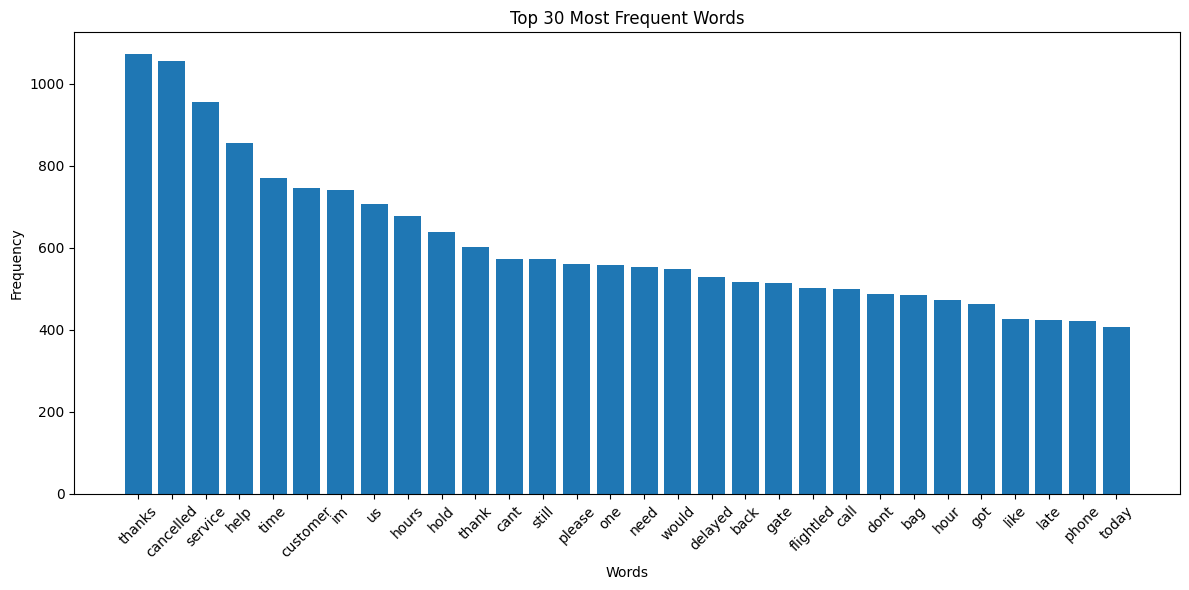

In [81]:
df = preprocess_dataset(df, text_column)
inspect_preprocessed_data(df, text_column, top_n=30)
plot_top_words(df, top_n=30)

### Text Preprocessing & Word Frequency

After preprocessing, the tweets are reduced to clean tokens, removing noise such as mentions, punctuation, and stopwords.

A small number of tweets become empty after cleaning, which is expected due to aggressive filtering.

The most frequent words are strongly related to customer experience (e.g., *service, help, delayed, hours*), indicating that the dataset is dominated by complaints and service-related issues.

This aligns with the class imbalance observed earlier, where negative sentiment is the majority.

In [82]:
tokenized_sentences = df["cleaned_tokens"].tolist()

word2vec_model = train_word2vec(
    tokenized_sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [83]:
print("\nWord2Vec model trained successfully.")
print("Vocabulary size:", len(word2vec_model.wv))


Word2Vec model trained successfully.
Vocabulary size: 5644


### Word2Vec Training

The Word2Vec model was successfully trained on the preprocessed corpus, resulting in a vocabulary of 5,644 unique tokens.

This indicates that the model has captured a sufficiently rich set of word representations from the dataset, allowing it to learn meaningful semantic relationships between words.

In [84]:
test_words = ["cancelled", "service", "help", "delayed"]
inspect_similar_words(word2vec_model, test_words, top_n=5)

X = create_feature_matrix(df["cleaned_tokens"].tolist(), word2vec_model)
y = df["airline_sentiment"].copy()

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst tweet vector (first 10 values):")
print(X[0][:10])


Most similar words:

Word: 'cancelled'
tomorrow: 0.9050
reschedule: 0.8867
rebook: 0.8836
hours: 0.8803
hold: 0.8802

Word: 'service'
worst: 0.9840
ever: 0.9751
experience: 0.9581
experienced: 0.9543
terrible: 0.9451

Word: 'help'
need: 0.9986
cant: 0.9985
find: 0.9985
online: 0.9984
ticket: 0.9984

Word: 'delayed'
two: 0.9986
sitting: 0.9981
delay: 0.9978
counting: 0.9975
almost: 0.9975

Feature matrix shape: (14640, 100)
Target shape: (14640,)

First tweet vector (first 10 values):
[-0.18529941  0.50760585  0.08019672 -0.22234364  0.22595602 -0.70182389
  0.25055984  1.08935118 -0.07113481 -0.30686116]


### Word Embeddings & Feature Representation

The Word2Vec model captures meaningful semantic relationships between words, as shown by the similarity results (e.g., *service → worst, terrible* and *cancelled → reschedule, rebook*).

Each tweet is then represented as a 100-dimensional vector by averaging its word embeddings.

This results in a feature matrix of shape (14640, 100), which is used as input to the neural network for classification.

In [86]:
y_encoded = encode_labels(y)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y_encoded)

X_train, X_val, X_test, y_train, y_val, y_test = to_tensors(
    X_train, X_val, X_test, y_train, y_val, y_test
)

train_loader, val_loader, test_loader = create_dataloaders(
    X_train, X_val, X_test, y_train, y_val, y_test
)

In [87]:
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 732
Validation batches: 92
Test batches: 92


### Data Preparation

The dataset is split into training, validation, and test sets, preserving the class distribution.

Mini-batches are created for efficient training, resulting in 732 training batches and 92 batches for both validation and testing.

In [88]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [89]:
model = ANNClassifier(
    input_dim=X_train.shape[1],
    hidden_dim1=128,
    hidden_dim2=64,
    output_dim=3,
    dropout_p1=0.2,
    dropout_p2=0.2
).to(device)

print(model)

ANNClassifier(
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=3, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (dropout2): Dropout(p=0.2, inplace=False)
)


### Model Architecture

A feed-forward neural network (ANN) is used for classification, consisting of two hidden layers (128 and 64 neurons) with ReLU activations.

Dropout is applied after each hidden layer to reduce overfitting, while the output layer maps to the three sentiment classes.

In [90]:
class_counts = np.bincount(y_train.cpu().numpy())
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [7343 2479 1890]
Class weights: [0.12743291 0.37746665 0.49510044]


### Handling Class Imbalance

The dataset is imbalanced, with the negative class significantly larger than the neutral and positive classes.

To address this, class weights are computed and applied in the loss function, giving higher importance to minority classes during training.

This helps the model avoid bias toward the dominant class and improves performance on underrepresented sentiments.

In [91]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=100,
    patience=5
)

Epoch [1/100] | Train Loss: 1.0904 | Val Loss: 1.0780 | Train Acc: 0.5050 | Val Acc: 0.6372
Epoch [2/100] | Train Loss: 1.0649 | Val Loss: 1.0405 | Train Acc: 0.5451 | Val Acc: 0.6277
Epoch [3/100] | Train Loss: 1.0259 | Val Loss: 1.0071 | Train Acc: 0.5373 | Val Acc: 0.4980
Epoch [4/100] | Train Loss: 1.0017 | Val Loss: 0.9858 | Train Acc: 0.5365 | Val Acc: 0.5700
Epoch [5/100] | Train Loss: 0.9820 | Val Loss: 0.9743 | Train Acc: 0.5365 | Val Acc: 0.5883
Epoch [6/100] | Train Loss: 0.9701 | Val Loss: 0.9599 | Train Acc: 0.5406 | Val Acc: 0.5360
Epoch [7/100] | Train Loss: 0.9588 | Val Loss: 0.9600 | Train Acc: 0.5427 | Val Acc: 0.4946
Epoch [8/100] | Train Loss: 0.9563 | Val Loss: 0.9486 | Train Acc: 0.5365 | Val Acc: 0.5842
Epoch [9/100] | Train Loss: 0.9510 | Val Loss: 0.9511 | Train Acc: 0.5479 | Val Acc: 0.5122
Epoch [10/100] | Train Loss: 0.9420 | Val Loss: 0.9473 | Train Acc: 0.5549 | Val Acc: 0.5795
Epoch [11/100] | Train Loss: 0.9414 | Val Loss: 0.9417 | Train Acc: 0.5527 | Va

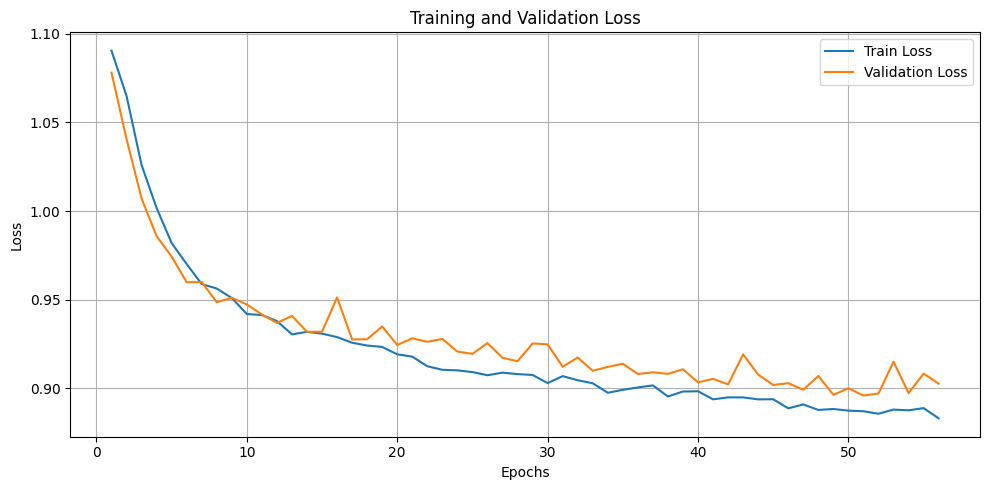

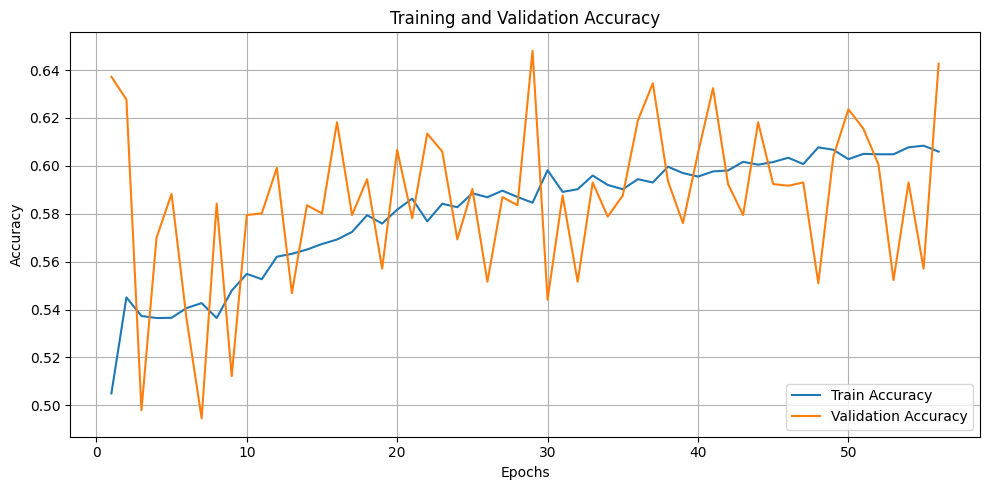


Test Set Evaluation Metrics:
Accuracy : 0.6366
Precision: 0.6877
Recall   : 0.6366
F1-score : 0.6517

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.66      0.74       918
     neutral       0.43      0.57      0.49       310
    positive       0.45      0.62      0.52       236

    accuracy                           0.64      1464
   macro avg       0.57      0.62      0.58      1464
weighted avg       0.69      0.64      0.65      1464



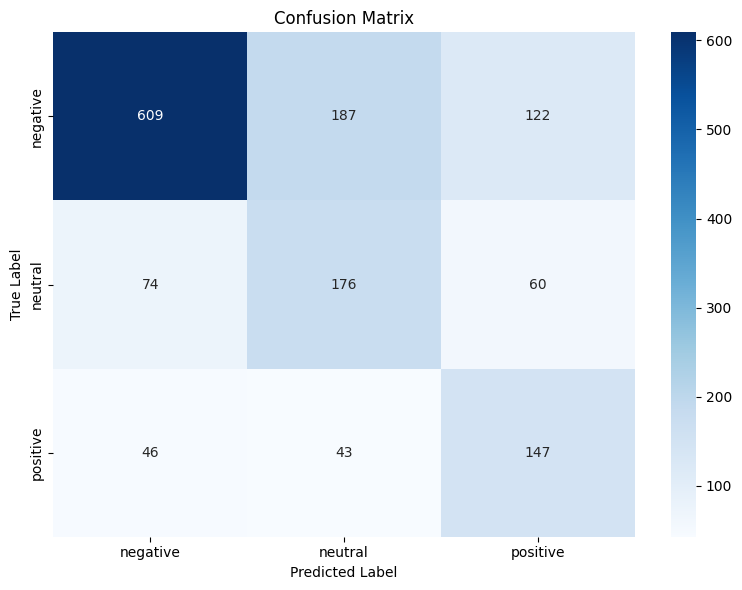

In [92]:
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

y_true, y_pred = evaluate_model(model, test_loader, device)

print_classification_metrics(y_true, y_pred)
plot_confusion_matrix(y_true, y_pred)

### Training Performance & Evaluation

The model shows stable convergence, with both training and validation loss decreasing smoothly, indicating no significant overfitting.

Accuracy improves steadily during training, while validation accuracy fluctuates slightly, which is expected due to dataset noise and class imbalance.

Early stopping is triggered at epoch 56, ensuring that the best-performing model is retained.

The final model achieves:
- Accuracy: ~0.64
- Weighted F1-score: ~0.65

The confusion matrix shows that the model performs well on the dominant negative class, while also improving recall for neutral and positive classes. However, some confusion remains between these classes, highlighting the difficulty of distinguishing less explicit sentiment.

### Final Conclusions

We used only the "text" column as input and "airline_sentiment" as the target variable, focusing strictly on textual sentiment classification and avoiding additional metadata to keep the model simple and interpretable.

The Word2Vec embeddings proved effective, as similar words were grouped meaningfully, indicating that the model captured useful semantic relationships within the corpus.

Initially, the model was biased toward the dominant negative class, leading to poor recall for neutral and positive tweets. After applying class weighting, performance became more balanced across all classes.

Although overall accuracy slightly decreased, recall for the minority classes improved significantly, which is more important in this imbalanced setting.

The final model achieved an accuracy of approximately 0.63–0.64 and a weighted F1-score of around 0.65, demonstrating a good trade-off between precision and recall.

The model performs strongly on negative sentiment while also capturing a meaningful portion of neutral and positive cases. However, neutral sentiment remains the most challenging class due to its ambiguous nature.

Overall, this work shows that combining Word2Vec embeddings with a feed-forward neural network can effectively model sentiment in noisy social media data, especially when class imbalance is properly handled.